In [1]:
import pandas as pd

In [2]:
df_area_irrigada = pd.read_csv('./datasets/dados_de_irrigacao.csv')

In [3]:
df_area_irrigada.info()

<class 'pandas.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 3 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Horas de Irrigação        299 non-null    int64  
 1   Área Irrigada             299 non-null    int64  
 2   Área Irrigada por Ângulo  299 non-null    float64
dtypes: float64(1), int64(2)
memory usage: 7.1 KB


In [4]:
df_area_irrigada.head(10)

,Horas de Irrigação,Área Irrigada,Área Irrigada por Ângulo
0,1,100,66.666667
1,2,200,133.333333
2,3,300,200.000000
3,4,400,266.666667
4,5,500,333.333333
5,6,600,400.000000
6,7,700,466.666667
7,8,800,533.333333
8,9,900,600.000000
9,10,1000,666.666667


In [5]:
df_area_irrigada.tail(10)

,Horas de Irrigação,Área Irrigada,Área Irrigada por Ângulo
289,290,29000,19333.333333
290,291,29100,19400.000000
291,292,29200,19466.666667
292,293,29300,19533.333333
293,294,29400,19600.000000
294,295,29500,19666.666667
295,296,29600,19733.333333
296,297,29700,19800.000000
297,298,29800,19866.666667
298,299,29900,19933.333333


In [12]:
# Renomear colunas para facilitar analise
df_area_irrigada.rename(columns={'Horas de Irrigação': 'horas_irrigacao', 
                                 'Área Irrigada': 'area_irrigada',
                                 'Área Irrigada por Ângulo': 'area_irrigada_por_angulo'}
                        , inplace=True)

In [13]:
df_area_irrigada.head(10)

,horas_irrigacao,area_irrigada,area_irrigada_por_angulo
0,1,100,66.666667
1,2,200,133.333333
2,3,300,200.000000
3,4,400,266.666667
4,5,500,333.333333
5,6,600,400.000000
6,7,700,466.666667
7,8,800,533.333333
8,9,900,600.000000
9,10,1000,666.666667


### EDA

In [14]:
df_area_irrigada.describe()

,horas_irrigacao,area_irrigada,area_irrigada_por_angulo
count,299.000000,299.000000,299.000000
mean,150.000000,15000.000000,10000.000000
std,86.458082,8645.808233,5763.872155
min,1.000000,100.000000,66.666667
25%,75.500000,7550.000000,5033.333333
50%,150.000000,15000.000000,10000.000000
75%,224.500000,22450.000000,14966.666667
max,299.000000,29900.000000,19933.333333


In [15]:
# Para fazer o Plot de Dispersão, iremso importar o Seaborn
import seaborn as sns

<Axes: xlabel='horas_irrigacao', ylabel='area_irrigada_por_angulo'>

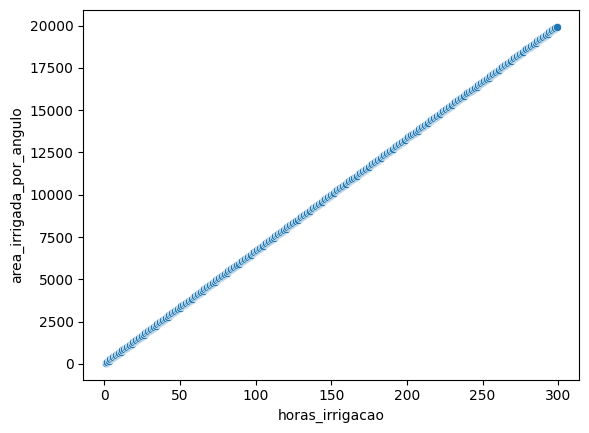

In [16]:
# Plot de Dispersão, com a variavel y sendo a dependente
# x = horas_irrigacao
# y = area_irrigada_por_angulo
sns.scatterplot(data=df_area_irrigada, x='horas_irrigacao', y='area_irrigada_por_angulo')

Com base no grafico, o H0 diz que os dados parecem seguir uma distribuição normal (Regressão Linear Simples), eles seguem a equação da reta.

<Axes: ylabel='area_irrigada_por_angulo'>

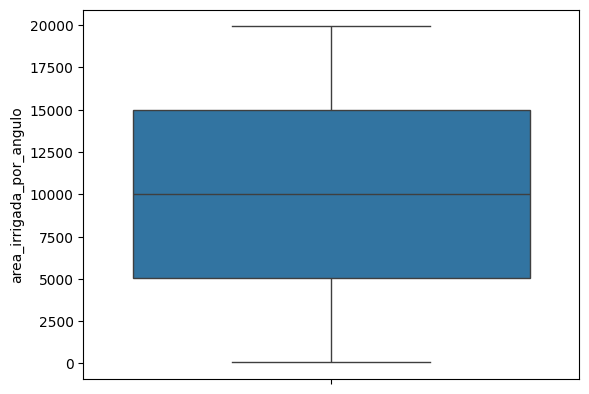

In [17]:
# Verificar OutLiers
sns.boxplot(df_area_irrigada, y='area_irrigada_por_angulo')

<Axes: ylabel='horas_irrigacao'>

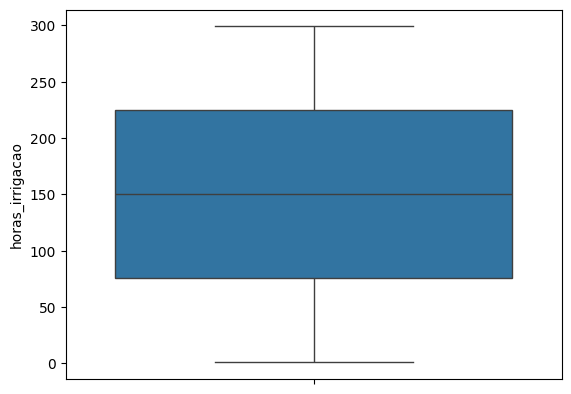

In [19]:
sns.boxplot(df_area_irrigada, y='horas_irrigacao')

<Axes: >

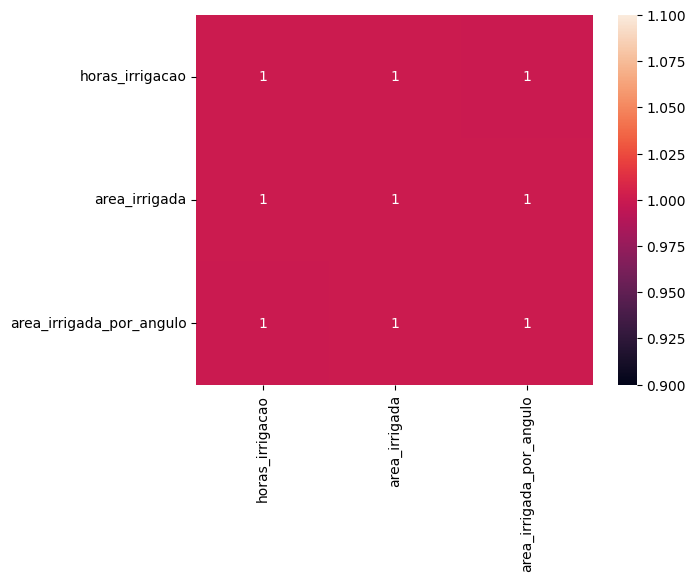

In [20]:
# Verificar correlação de Pearson para validar a correlação linear entra duas variaveis
sns.heatmap(df_area_irrigada.corr('pearson'), annot=True)

Correlação perfeita pelo numero ser igual a 1, quanto mais proximo de 1, melhor a correlação entre as variaveis segundo o metodo de Pearson

<Axes: >

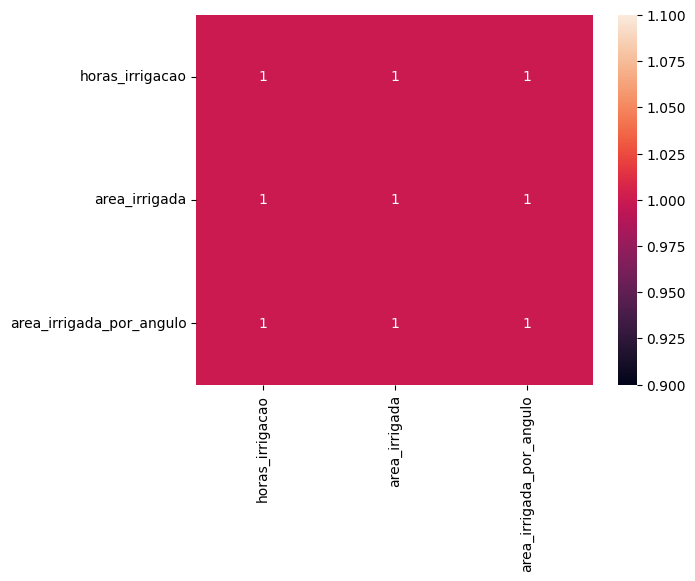

In [21]:
# Verificando correlação de Spearman (Para situação não linear)
sns.heatmap(df_area_irrigada.corr('spearman'), annot=True)

Correlação perfeita entre as variaveis, segundo correlação de Spearman, para correlações não lineares

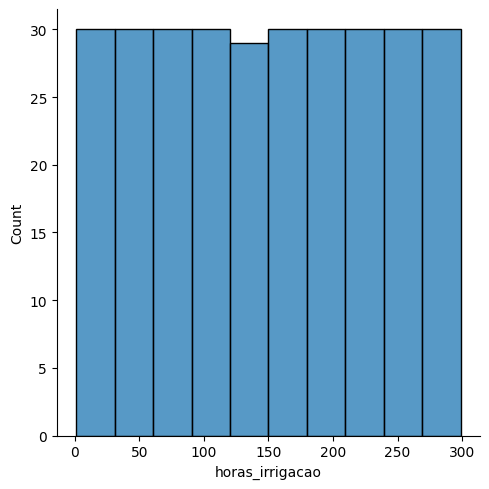

In [22]:
# Histograma das variaveis para ver como é a distribuição
sns.displot(df_area_irrigada, x='horas_irrigacao')

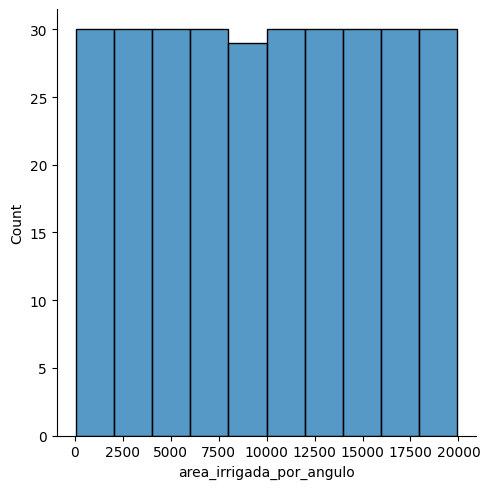

In [23]:
sns.displot(df_area_irrigada, x='area_irrigada_por_angulo')

Conclusão

- Não existe ouliers
- A forma do plano cartesiano indica um forte padrão para aplicar o modelo linear, sendo quase uma equação da reta perfeita, tendo minimos pontos saltando da equação da reta.
- Com base no indice de correlação de Spearman e Pearson, as features tem uma correlação perfeita com a variavel dependente.

### Treinar Modelo

In [24]:
# Dividar o dataset em dados de treino e de teste
# Como iremos utilizar apenas 1 feature, iremos ajustar o shape
X = df_area_irrigada['horas_irrigacao'].values.reshape(-1,1)

y = df_area_irrigada['area_irrigada_por_angulo'].values.reshape(-1,1)

In [25]:
# Importar função para dividir os dados entre treino e teste
from sklearn.model_selection import train_test_split

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=50, test_size=0.30)

In [27]:
# Instanciar modelo a ser treinado
from sklearn.linear_model import LinearRegression

reg_model = LinearRegression()

In [28]:
# Treinar Modelo
reg_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [31]:
# Imprimir a equação da reta
print("A equação da reta é y = {:4f}x + {:4f}".format(reg_model.coef_[0][0], reg_model.intercept_[0]))

A equação da reta é y = 66.666667x + -0.000000


### Validar Modelo - Métricas

In [32]:
# Predição dos valores com base no conjunto de teste
y_pred = reg_model.predict(X_test)

In [33]:
# Calcular métrica R-squared ou Coeficiente de Determinação
# R2 representa a proporção na variação na variavel dependente que é explicada pela variavel independente
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


In [34]:
r2_score(y_test, y_pred)

1.0

In [35]:
# Calcular métrica MAE (Mean Absolute Error) - Diferença entre o valor predito e o valor de teste
# MAE = Media (y_test - y_pred)
# É uma métrica fácil de interpretar
# MAE é menos sensivel a outliers

mean_absolute_error(y_test, y_pred)

1.6854073692229576e-12

In [37]:
import numpy as np

In [38]:
# Calcular métrica MSE (Mean Squared Error)
# MSE = Média (y_test - y_pred)^2
# Não é uma métrica fácil de interpretar
# MSE é mais sensivel a outliers e penaliza grandes erros

np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(2.2692262554245704e-12)

In [39]:
import matplotlib.pyplot as plt

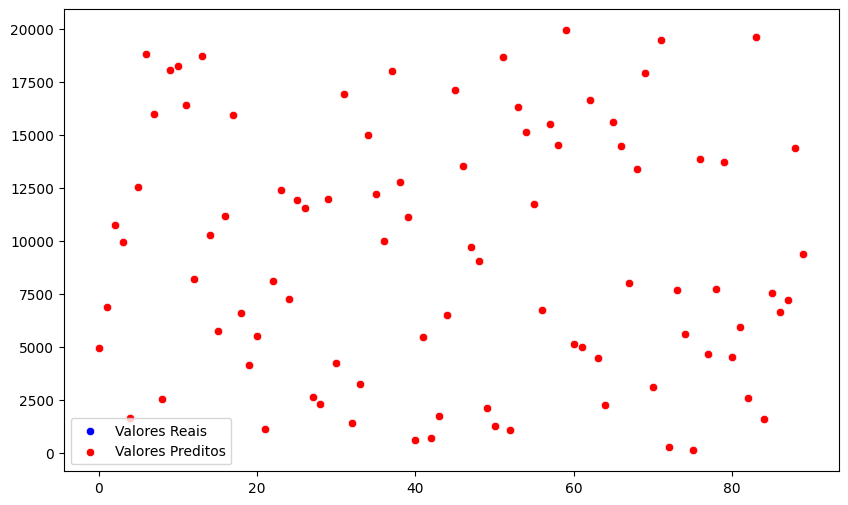

In [40]:
# Analise Gráfica
x_axis = range(len(y_test))
plt.figure(figsize=(10,6))
sns.scatterplot(x=x_axis, y=y_test.reshape(-1), color='blue', label='Valores Reais')
sns.scatterplot(x=x_axis, y=y_pred.reshape(-1), color='Red', label='Valores Preditos')
plt.legend()
plt.show()

### Analise de Residuos

In [41]:
# Calcular residuos
residuos = y_test - y_pred

In [42]:
# Calcular os residuos padronizados (standardization)
# Para cada elemento de um conjunto (X - media) / desvio_padrao
from scipy.stats import zscore

residuos_std = zscore(residuos)

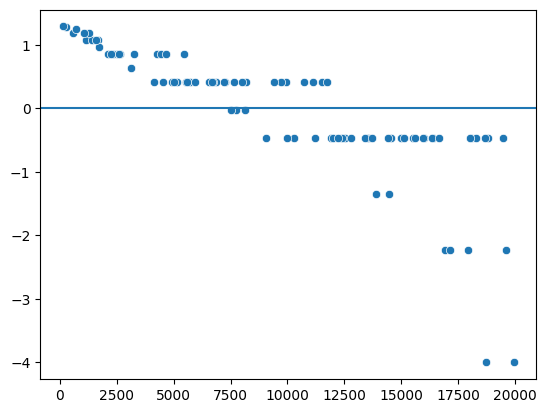

In [43]:
# Verificar linearidade do modelo:
# Se os residuos estiverem entre -2 e +2 (na escala padrão) - indica linearidade

# Verificar homogeneidade das variancias (Homocedasticidade)
# Valores estiver em torno da reta, temos homocedasticidade, caso contrári
# se tivermos alguma tendência ou padrão (formam um cone, funil), há heterocedasticidade

sns.scatterplot(x=y_pred.reshape(-1), y=residuos_std.reshape(-1))
plt.axhline(y=0)

In [44]:
# Checar se residuos seguem uma distribuição normal
# QQ (Quantile-Quantile) Plot, que avalia se uma amostra segue uma distribuição normal
import pingouin as pg

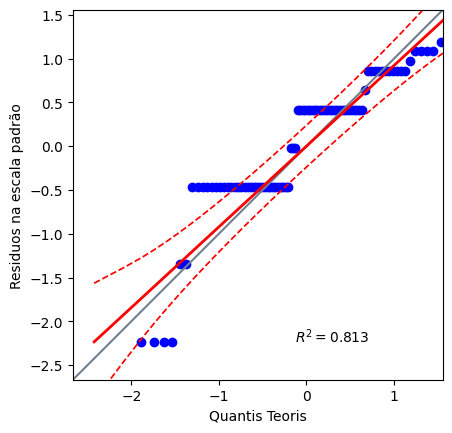

In [45]:
pg.qqplot(residuos_std, dist='norm', confidence=0.95)
plt.xlabel('Quantis Teoris')
plt.ylabel('Residuos na escala padrão')
plt.show()

Conforme o gráfico demonstra, ele diz que o modelo treinado para alguns pontos, nao tem um bom comportamento para o modelo Regressão Linear, tem diversos pontos que estão saindo da reta e pontos não estão proximos da reta, até estão bem proximos, mas tem alguns que escapam mais e estão quase no limite de referência.

- Não indica uma forte lineariadade
- Não tem Homocedasticidade

O modelo não irá fazer boas predições com base nesses gráficos.

### Teste de Normalidade

- H0 - A Hipotese nula diz o seguinte, os dados parecem seguir uma distribuição normal.
- H1 - A Hipotese Alternativa, os residuos mostram que os dados não seguem uma distribuição normal.

In [49]:
from scipy.stats import shapiro, kstest

In [48]:
# Teste de Normalidade - Shapiro Wilk
# Quanto mais próximo de 1, melhor
# P-Value for maior que 0.05 não rejeita H0, caso contrário, rejeitamos

stat_shapiro, p_valor_shapiro = shapiro(residuos.reshape(-1))
print("Estatistica do teste: {} e P-Valor: {}".format(stat_shapiro,p_valor_shapiro))

Estatistica do teste: 0.8172696879209803 e P-Valor: 3.4725200145985586e-09


Conclusão: Pelo p-valor de shapiro ser menor que 0.05, rejeitamos o H0, então seguimos que esse modelo segue não é uma distribuição normal

In [51]:
# Teste de Normalidade - Kolmogorov-Smirnov
# Quanto mais próximo de 1, melhor
# P-Value for maior que 0.05 não rejeita H0, caso contrário, rejeitamos

stat_ks, p_valor_ks = kstest(residuos.reshape(-1), 'norm')
print("Estatistica do teste: {} e P-Valor: {}".format(stat_ks,p_valor_ks))

Estatistica do teste: 0.49999999999856004 e P-Valor: 2.486951502308412e-21


Conclusão: Pelo p-valor de ks ser menos que 0.05, rejeitamos o H0, então seguimos que esse modelo não segue uma distribuição normal

### Fazer predições com o modelo

In [52]:
reg_model.predict([[15]])

array([[1000.]])

Conclui-se pelas validações que dentre desse universo, com essas informações, o modelo se comportou bem e conseguiu na predição um bom resultado com um erro médio minimo, na casa dos 0000000.

Porém, ao verificar os residuos e a normalidade, foi constatado que o comportamento foi bem ruim para ser considerado uma distribuição normal, apresentou resultados insatisfatorios para o modelo